In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.svm import OneClassSVM
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, RobustScaler
from sklearn.pipeline import Pipeline

In [3]:
df = pd.read_csv(
    "../data/raw/PMAY-U_2025_dataset.csv"
)

df = df.rename(columns={
    df.columns[0]: "Country",
    df.columns[1]: "State",
    df.columns[2]: "Year",
    df.columns[3]: "City",
    df.columns[4]: "Investment",
    df.columns[5]: "Central_assistance_sanctioned",
    df.columns[6]: "Central_assistance_released",
    df.columns[7]: "Houses_sanctioned",
    df.columns[8]: "Houses_grounded",
    df.columns[9]: "Houses_completed"
})

In [4]:
numerical_features = [
    "Investment",
    "Central_assistance_sanctioned",
    "Central_assistance_released",
    "Houses_sanctioned",
    "Houses_grounded",
    "Houses_completed"
]

X = df[numerical_features].copy()

for column in numerical_features:
    X[column] = pd.to_numeric(
        X[column],
        errors="coerce"
    )

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

In [5]:
final_preprocessor = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "power_transform",
        PowerTransformer(
            method="yeo-johnson",
            standardize=False
        )
    ),
    (
        "scaler",
        RobustScaler()
    )
])

X_final_processed = final_preprocessor.fit_transform(X)

print(
    "Final processed dataset:",
    X_final_processed.shape
)

Final processed dataset: (5113, 6)


In [6]:
final_model = OneClassSVM(
    kernel="rbf",
    nu=0.15,
    gamma=0.05
)

final_model.fit(X_final_processed)

,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.05
,"nu nu: float, default=0.5An upper bound on the fraction of trainingerrors and a lower bound of the fraction of supportvectors. Should be in the interval (0, 1]. By default 0.5will be taken.",0.15
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1
Name,Type,Value


In [7]:
final_scores = -final_model.decision_function(
    X_final_processed
)

final_predictions = final_model.predict(
    X_final_processed
)

In [8]:
final_anomaly_report = df.copy()

final_anomaly_report["Anomaly_Score"] = final_scores

final_anomaly_report["Anomaly_Label"] = np.where(
    final_predictions == -1,
    "Anomaly",
    "Normal"
)

final_anomaly_report["Anomaly_Rank"] = (
    final_anomaly_report["Anomaly_Score"]
    .rank(
        ascending=False,
        method="first"
    )
    .astype(int)
)

final_anomaly_report = final_anomaly_report.sort_values(
    "Anomaly_Score",
    ascending=False
)

final_anomaly_report.head(20)

,Country,State,Year,City,Investment,Central_assistance_sanctioned,Central_assistance_released,Houses_sanctioned,Houses_grounded,Houses_completed,Anomaly_Score,Anomaly_Label,Anomaly_Rank
783,India,Gujarat,"Calendar Year (Jan - Dec), 2025",Ahmedabad Municipal Corporation,25327.17,4349.10,4035.68,207593.0,205196.0,194423.0,258.062654,Anomaly,1
944,India,Gujarat,"Calendar Year (Jan - Dec), 2025",Surat Municipal Corporation,19765.68,3635.89,3599.23,163486.0,161968.0,161225.0,240.157612,Anomaly,2
2402,India,Maharashtra,"Calendar Year (Jan - Dec), 2025",Pune Municipal Corporation,26124.59,3375.63,3072.19,155747.0,150077.0,148161.0,236.606778,Anomaly,3
3946,India,Telangana,"Calendar Year (Jan - Dec), 2025",Hyderabad Municipal Corporation,18800.31,2593.68,2075.28,150782.0,143207.0,131236.0,225.771419,Anomaly,4
139,India,Andhra Pradesh,"Calendar Year (Jan - Dec), 2025",Visakhapattnam Municipal Corporation,8799.70,2649.17,2104.86,168961.0,162171.0,91344.0,216.630458,Anomaly,5
1313,India,Karnataka,"Calendar Year (Jan - Dec), 2025",Bengaluru Municipal Corporation,20837.81,2454.33,2127.72,136578.0,124019.0,88666.0,211.262497,Anomaly,6
2218,India,Maharashtra,"Calendar Year (Jan - Dec), 2025",Greater Mumbai Municipal Corporation,7324.68,1634.56,374.56,141515.0,141515.0,137793.0,210.028610,Anomaly,7
3272,India,Tamil Nadu,"Calendar Year (Jan - Dec), 2025",Chennai Municipal Corporation,13411.39,1735.12,1466.82,97779.0,96138.0,76843.0,185.560934,Anomaly,8
12,India,Andhra Pradesh,"Calendar Year (Jan - Dec), 2025",Andhra Pradesh Capital Region Development,4221.74,1669.97,1521.55,111154.0,110196.0,49578.0,171.788127,Anomaly,9
921,India,Gujarat,"Calendar Year (Jan - Dec), 2025",Rajkot Municipal Corporation,9409.46,1676.70,1597.06,75976.0,75800.0,74573.0,170.346232,Anomaly,10


In [9]:
final_anomaly_count = np.sum(
    final_predictions == -1
)

final_normal_count = np.sum(
    final_predictions == 1
)

print("Total records:", len(df))
print("Normal records:", final_normal_count)
print("Anomalous records:", final_anomaly_count)

print(
    "Anomaly percentage:",
    round(
        final_anomaly_count / len(df) * 100,
        2
    ),
    "%"
)

Total records: 5113
Normal records: 4347
Anomalous records: 766
Anomaly percentage: 14.98 %


In [10]:
final_anomaly_report["Priority"] = pd.cut(
    final_anomaly_report["Anomaly_Rank"],
    bins=[
        0,
        int(len(df) * 0.01),
        int(len(df) * 0.05),
        int(len(df) * 0.10),
        len(df)
    ],
    labels=[
        "Critical",
        "High",
        "Moderate",
        "Low"
    ],
    include_lowest=True
)

In [11]:
top_20 = final_anomaly_report[
    [
        "Anomaly_Rank",
        "State",
        "City",
        "Investment",
        "Central_assistance_sanctioned",
        "Central_assistance_released",
        "Houses_sanctioned",
        "Houses_grounded",
        "Houses_completed",
        "Anomaly_Score",
        "Priority"
    ]
].head(20)

display(top_20)

,Anomaly_Rank,State,City,Investment,Central_assistance_sanctioned,Central_assistance_released,Houses_sanctioned,Houses_grounded,Houses_completed,Anomaly_Score,Priority
783,1,Gujarat,Ahmedabad Municipal Corporation,25327.17,4349.10,4035.68,207593.0,205196.0,194423.0,258.062654,Critical
944,2,Gujarat,Surat Municipal Corporation,19765.68,3635.89,3599.23,163486.0,161968.0,161225.0,240.157612,Critical
2402,3,Maharashtra,Pune Municipal Corporation,26124.59,3375.63,3072.19,155747.0,150077.0,148161.0,236.606778,Critical
3946,4,Telangana,Hyderabad Municipal Corporation,18800.31,2593.68,2075.28,150782.0,143207.0,131236.0,225.771419,Critical
139,5,Andhra Pradesh,Visakhapattnam Municipal Corporation,8799.70,2649.17,2104.86,168961.0,162171.0,91344.0,216.630458,Critical
1313,6,Karnataka,Bengaluru Municipal Corporation,20837.81,2454.33,2127.72,136578.0,124019.0,88666.0,211.262497,Critical
2218,7,Maharashtra,Greater Mumbai Municipal Corporation,7324.68,1634.56,374.56,141515.0,141515.0,137793.0,210.028610,Critical
3272,8,Tamil Nadu,Chennai Municipal Corporation,13411.39,1735.12,1466.82,97779.0,96138.0,76843.0,185.560934,Critical
12,9,Andhra Pradesh,Andhra Pradesh Capital Region Development,4221.74,1669.97,1521.55,111154.0,110196.0,49578.0,171.788127,Critical
921,10,Gujarat,Rajkot Municipal Corporation,9409.46,1676.70,1597.06,75976.0,75800.0,74573.0,170.346232,Critical


In [12]:
final_anomaly_report.to_csv(
    "../experiments/results/final_anomaly_report.csv",
    index=False
)

joblib.dump(
    final_preprocessor,
    "../src/models/final_preprocessor.joblib"
)

joblib.dump(
    final_model,
    "../src/models/final_one_class_svm.joblib"
)

print("Final anomaly analysis saved.")

Final anomaly analysis saved.


Anomaly Explanation


In [13]:
def explain_anomaly(
    row,
    model,
    preprocessor,
    feature_names,
    reference_data
):
    """
    Estimate feature influence by replacing each feature
    with its reference median and measuring the change
    in anomaly score.
    """

    original = row[feature_names].copy()

    # Make sure numeric
    original = pd.to_numeric(
        original,
        errors="coerce"
    )

    original_df = pd.DataFrame(
        [original.values],
        columns=feature_names
    )

    # Original score
    original_processed = preprocessor.transform(
        original_df
    )

    original_score = -model.decision_function(
        original_processed
    )[0]

    results = []

    medians = reference_data[
        feature_names
    ].median()

    for feature in feature_names:

        modified = original.copy()

        modified[feature] = medians[feature]

        modified_df = pd.DataFrame(
            [modified.values],
            columns=feature_names
        )

        modified_processed = preprocessor.transform(
            modified_df
        )

        modified_score = -model.decision_function(
            modified_processed
        )[0]

        score_change = (
            original_score - modified_score
        )

        results.append({
            "Feature": feature,
            "Original_Value": original[feature],
            "Reference_Median": medians[feature],
            "Original_Score": original_score,
            "Modified_Score": modified_score,
            "Score_Change": score_change,
            "Absolute_Influence": abs(score_change)
        })

    explanation = pd.DataFrame(results)

    return explanation.sort_values(
        "Absolute_Influence",
        ascending=False
    )

In [14]:
ahmedabad = final_anomaly_report.loc[
    783
]

ahmedabad_explanation = explain_anomaly(
    row=ahmedabad,
    model=final_model,
    preprocessor=final_preprocessor,
    feature_names=numerical_features,
    reference_data=X
)

display(ahmedabad_explanation)

,Feature,Original_Value,Reference_Median,Original_Score,Modified_Score,Score_Change,Absolute_Influence
5,Houses_completed,194423.00,647.00,258.062654,246.855893,11.206762,11.206762
1,Central_assistance_sanctioned,4349.10,13.48,258.062654,266.183836,-8.121182,8.121182
2,Central_assistance_released,4035.68,10.85,258.062654,265.673700,-7.611045,7.611045
0,Investment,25327.17,41.66,258.062654,264.326653,-6.263998,6.263998
4,Houses_grounded,205196.00,739.00,258.062654,253.708333,4.354321,4.354321
3,Houses_sanctioned,207593.00,849.00,258.062654,255.523702,2.538952,2.538952


In [15]:
top_10_indices = (
    final_anomaly_report
    .head(10)
    .index
)

all_explanations = []

for index in top_10_indices:

    row = final_anomaly_report.loc[index]

    explanation = explain_anomaly(
        row=row,
        model=final_model,
        preprocessor=final_preprocessor,
        feature_names=numerical_features,
        reference_data=X
    )

    explanation["Record_Index"] = index
    explanation["State"] = row["State"]
    explanation["City"] = row["City"]

    all_explanations.append(
        explanation
    )

top10_explanations = pd.concat(
    all_explanations,
    ignore_index=True
)

display(top10_explanations)

,Feature,Original_Value,Reference_Median,Original_Score,Modified_Score,Score_Change,Absolute_Influence,Record_Index,State,City
0,Houses_completed,194423.00,647.00,258.062654,246.855893,11.206762,11.206762,783,Gujarat,Ahmedabad Municipal Corporation
1,Central_assistance_sanctioned,4349.10,13.48,258.062654,266.183836,-8.121182,8.121182,783,Gujarat,Ahmedabad Municipal Corporation
2,Central_assistance_released,4035.68,10.85,258.062654,265.673700,-7.611045,7.611045,783,Gujarat,Ahmedabad Municipal Corporation
3,Investment,25327.17,41.66,258.062654,264.326653,-6.263998,6.263998,783,Gujarat,Ahmedabad Municipal Corporation
4,Houses_grounded,205196.00,739.00,258.062654,253.708333,4.354321,4.354321,783,Gujarat,Ahmedabad Municipal Corporation
5,Houses_sanctioned,207593.00,849.00,258.062654,255.523702,2.538952,2.538952,783,Gujarat,Ahmedabad Municipal Corporation
6,Central_assistance_sanctioned,3635.89,13.48,240.157612,249.530705,-9.373093,9.373093,944,Gujarat,Surat Municipal Corporation
7,Houses_completed,161225.00,647.00,240.157612,230.805197,9.352415,9.352415,944,Gujarat,Surat Municipal Corporation
8,Central_assistance_released,3599.23,10.85,240.157612,248.550784,-8.393172,8.393172,944,Gujarat,Surat Municipal Corporation
9,Investment,19765.68,41.66,240.157612,248.166465,-8.008854,8.008854,944,Gujarat,Surat Municipal Corporation


In [16]:
feature_influence_summary = (
    top10_explanations
    .groupby("Feature")["Absolute_Influence"]
    .agg(
        Mean_Influence="mean",
        Median_Influence="median",
        Max_Influence="max"
    )
    .sort_values(
        "Mean_Influence",
        ascending=False
    )
)

display(feature_influence_summary)

,Mean_Influence,Median_Influence,Max_Influence
Feature,,,
Central_assistance_sanctioned,12.169281,11.844170,15.205190
Central_assistance_released,11.426879,11.092482,16.498696
Investment,11.068757,9.481281,20.986244
Houses_completed,7.321139,6.642576,13.892208
Houses_sanctioned,3.819270,2.480913,13.662888
Houses_grounded,3.116764,2.324715,9.881683


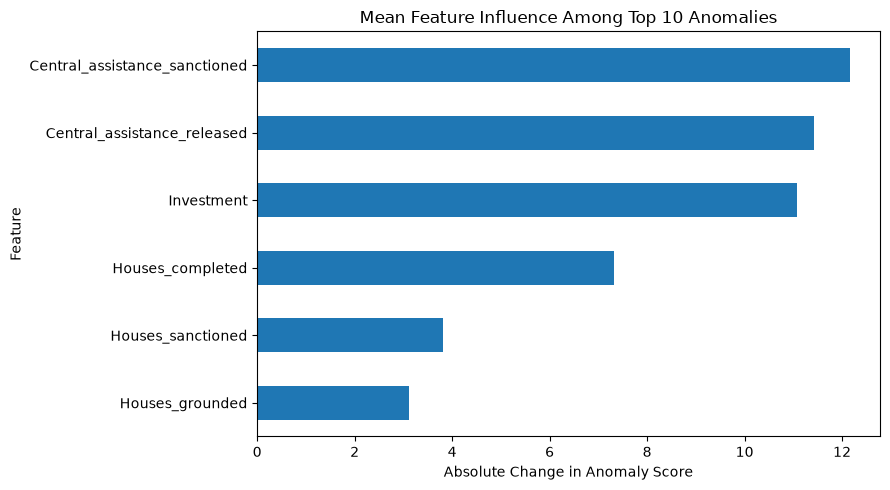

In [17]:
plt.figure(figsize=(9, 5))

feature_influence_summary[
    "Mean_Influence"
].sort_values().plot(
    kind="barh"
)

plt.title(
    "Mean Feature Influence Among Top 10 Anomalies"
)

plt.xlabel(
    "Absolute Change in Anomaly Score"
)

plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [18]:
top10_explanations.to_csv(
    "../experiments/results/top10_anomaly_explanations.csv",
    index=False
)

feature_influence_summary.to_csv(
    "../experiments/results/feature_influence_summary.csv"
)

print("Anomaly explanation results saved.")

Anomaly explanation results saved.


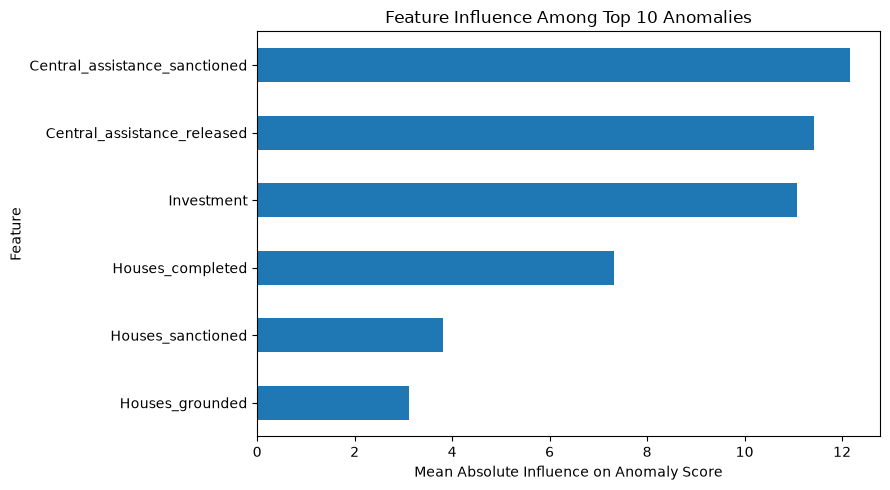

In [19]:
# Figure 3 — Feature Influence

plt.figure(figsize=(9, 5))

feature_influence_summary["Mean_Influence"].sort_values().plot(
    kind="barh"
)

plt.title("Feature Influence Among Top 10 Anomalies")
plt.xlabel("Mean Absolute Influence on Anomaly Score")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../reports/figures/feature_influence_top10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

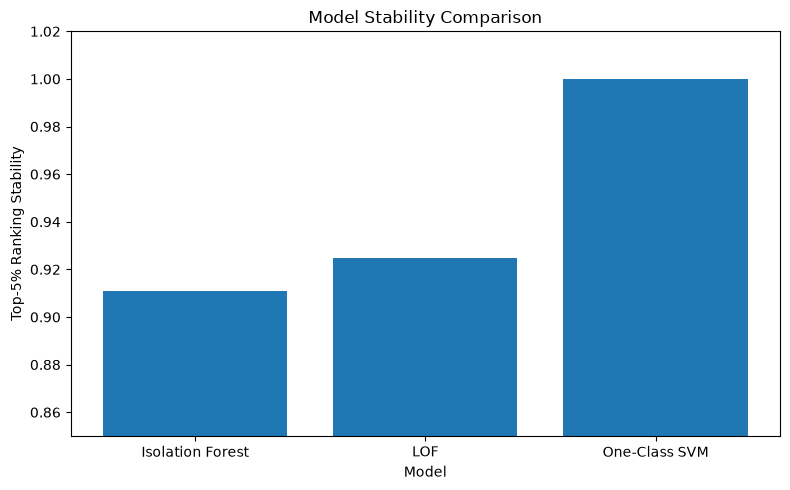

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

stability_df = pd.DataFrame({
    "Model": [
        "Isolation Forest",
        "LOF",
        "One-Class SVM"
    ],
    "Stability": [
        0.910806,
        0.924665,
        1.000000
    ]
})

plt.figure(figsize=(8, 5))

plt.bar(
    stability_df["Model"],
    stability_df["Stability"]
)

plt.ylim(0.85, 1.02)
plt.ylabel("Top-5% Ranking Stability")
plt.xlabel("Model")
plt.title("Model Stability Comparison")

plt.tight_layout()

plt.savefig(
    "../reports/figures/model_stability_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

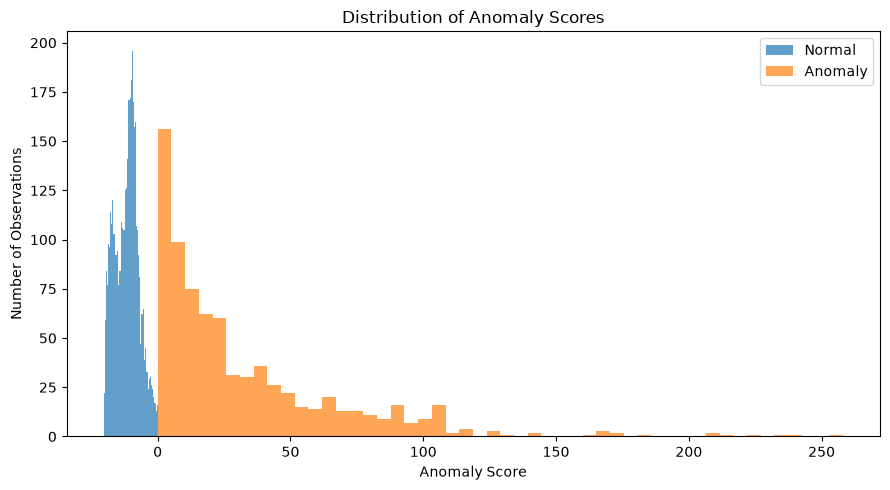

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.hist(
    final_anomaly_report.loc[
        final_anomaly_report["Anomaly_Label"] == "Normal",
        "Anomaly_Score"
    ],
    bins=50,
    alpha=0.7,
    label="Normal"
)

plt.hist(
    final_anomaly_report.loc[
        final_anomaly_report["Anomaly_Label"] == "Anomaly",
        "Anomaly_Score"
    ],
    bins=50,
    alpha=0.7,
    label="Anomaly"
)

plt.xlabel("Anomaly Score")
plt.ylabel("Number of Observations")
plt.title("Distribution of Anomaly Scores")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/figures/anomaly_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

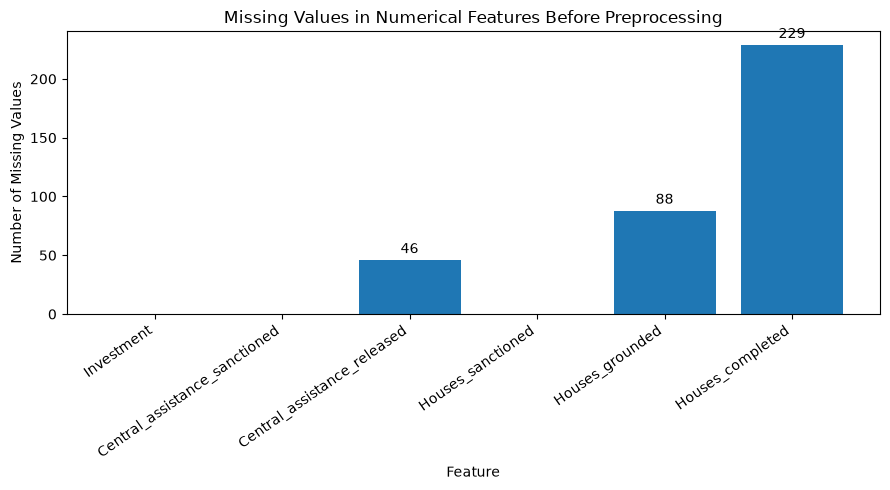

In [23]:
import matplotlib.pyplot as plt

missing_counts = df[numerical_features].isna().sum()

plt.figure(figsize=(9, 5))

bars = plt.bar(
    missing_counts.index,
    missing_counts.values
)

plt.ylabel("Number of Missing Values")
plt.xlabel("Feature")
plt.title("Missing Values in Numerical Features Before Preprocessing")

plt.xticks(
    rotation=35,
    ha="right"
)

# Add counts
for bar, value in zip(bars, missing_counts.values):
    if value > 0:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 3,
            str(value),
            ha="center",
            va="bottom"
        )

plt.tight_layout()

plt.savefig(
    "../reports/figures/missing_values_before_preprocessing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

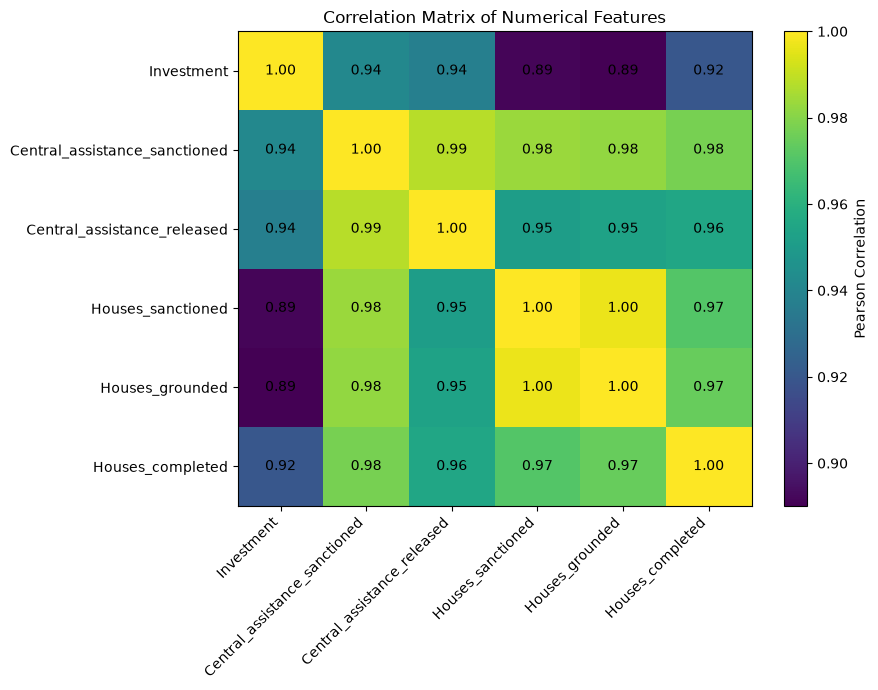

In [24]:
import matplotlib.pyplot as plt
import numpy as np

correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(9, 7))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(
    label="Pearson Correlation"
)

plt.xticks(
    range(len(numerical_features)),
    numerical_features,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(numerical_features)),
    numerical_features
)

plt.title("Correlation Matrix of Numerical Features")

# Add correlation values
for i in range(len(numerical_features)):
    for j in range(len(numerical_features)):
        value = correlation_matrix.iloc[i, j]

        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    "../reports/figures/numerical_feature_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

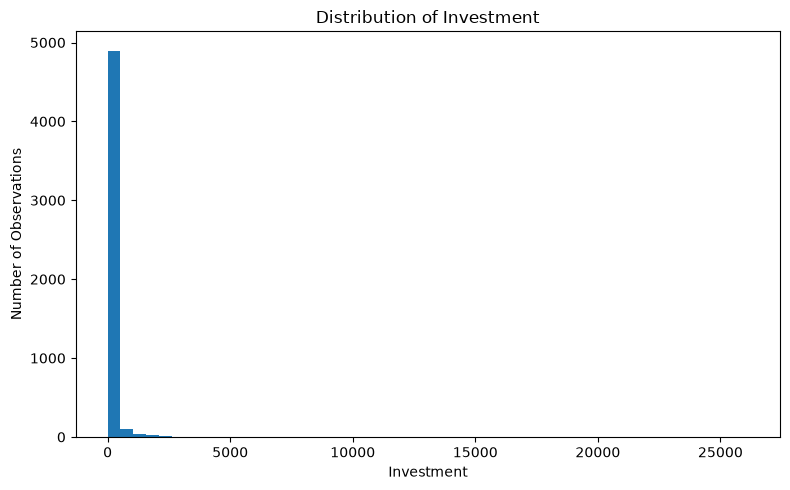

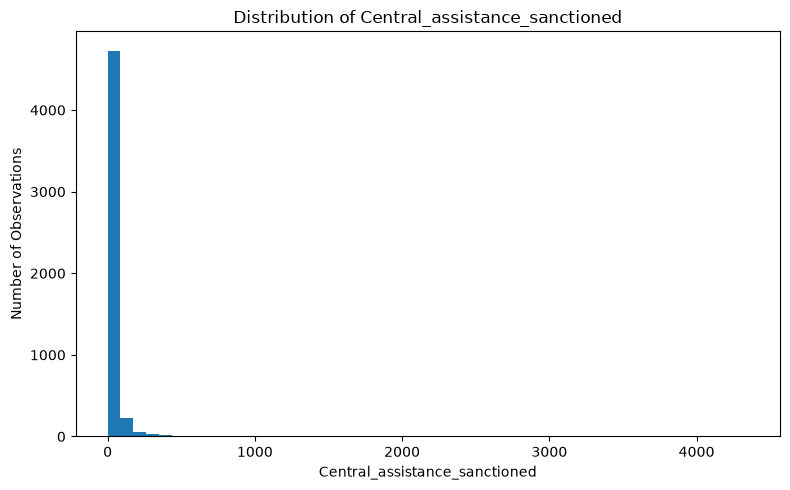

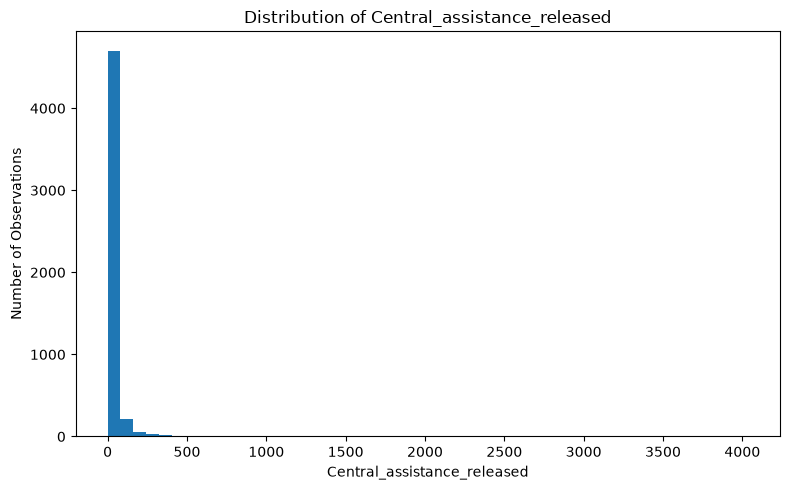

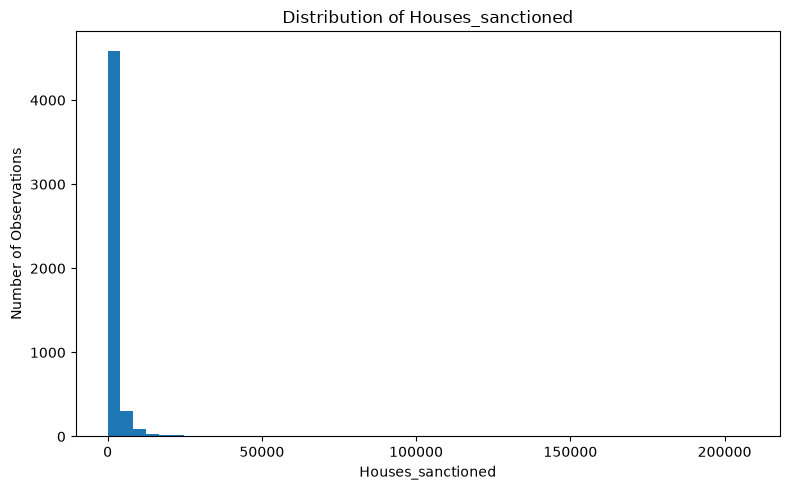

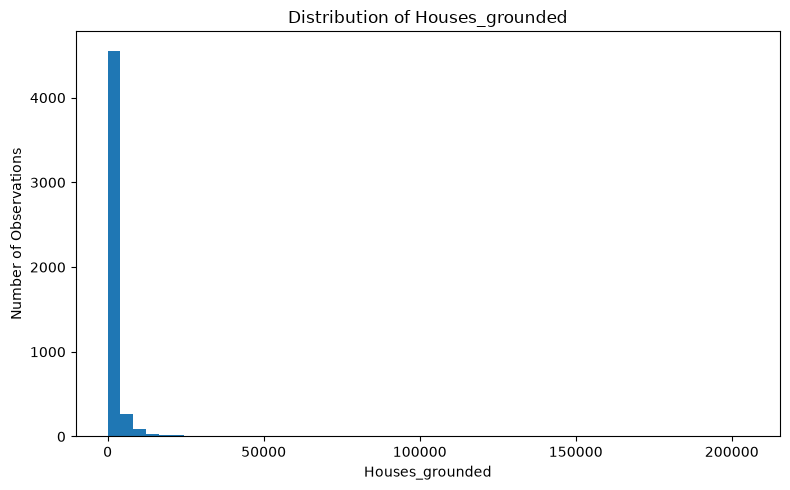

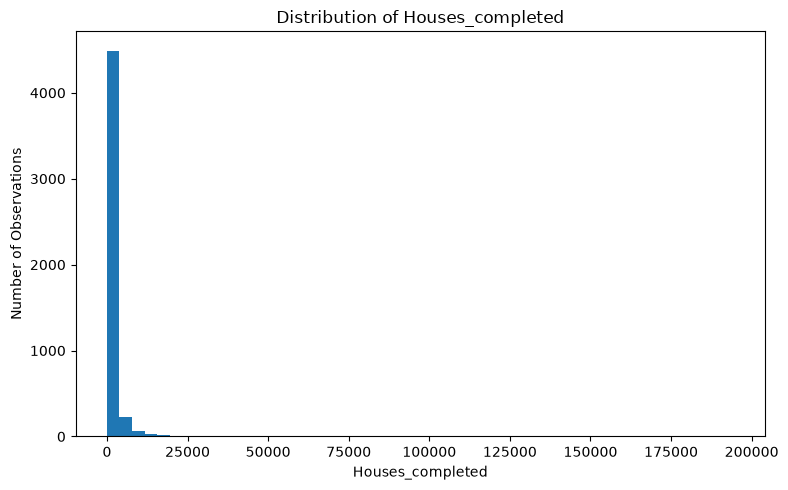

In [25]:
import matplotlib.pyplot as plt

for feature in numerical_features:

    plt.figure(figsize=(8, 5))

    plt.hist(
        df[feature].dropna(),
        bins=50
    )

    plt.xlabel(feature)
    plt.ylabel("Number of Observations")
    plt.title(f"Distribution of {feature}")

    plt.tight_layout()

    filename = feature.lower() + "_distribution.png"

    plt.savefig(
        f"../reports/figures/{filename}",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

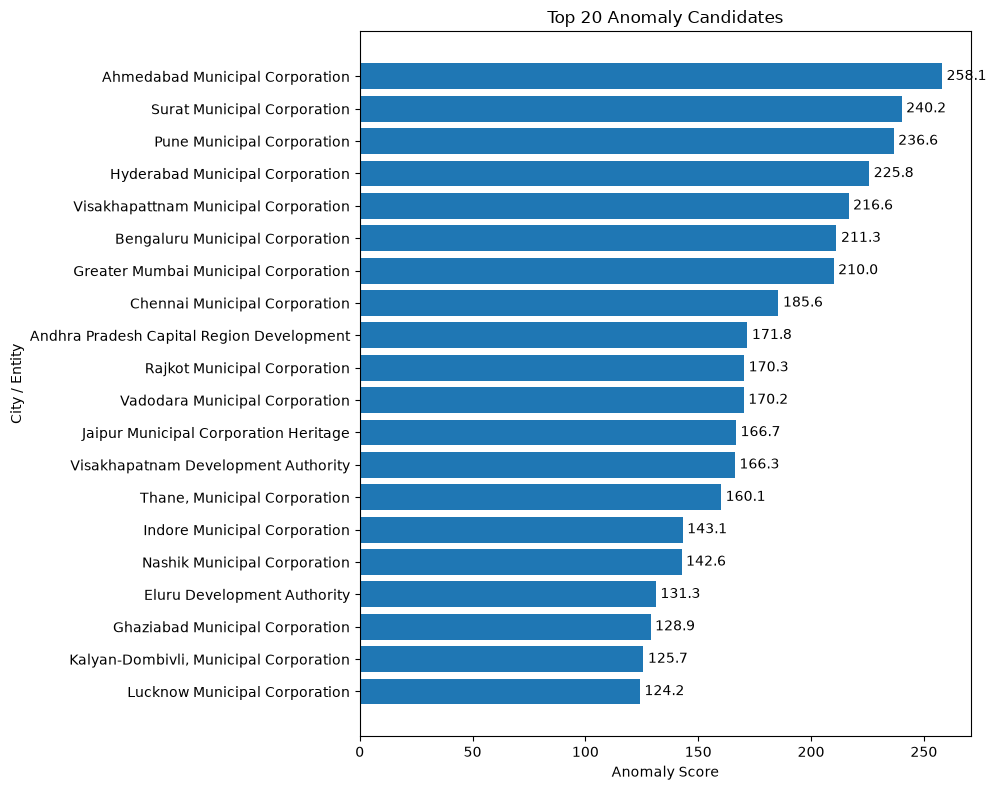

In [26]:
import matplotlib.pyplot as plt

top20 = (
    final_anomaly_report
    .sort_values("Anomaly_Score", ascending=False)
    .head(20)
    .copy()
)

# Reverse so highest score appears at top
top20 = top20.sort_values("Anomaly_Score", ascending=True)

# Create readable labels
labels = top20["City"].astype(str)

plt.figure(figsize=(10, 8))

bars = plt.barh(
    labels,
    top20["Anomaly_Score"]
)

plt.xlabel("Anomaly Score")
plt.ylabel("City / Entity")
plt.title("Top 20 Anomaly Candidates")

# Add score values
for bar, value in zip(bars, top20["Anomaly_Score"]):

    plt.text(
        value + 2,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "../reports/figures/top20_anomaly_candidates.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()